# 2.3.1 — Word count: the benchmarks

Measurements on the Cloud Veneto cluster (5 × `cloudveneto.large`: 1 scheduler + 4 workers with 4 cores and 7.1 GB each), August 2026, on the full corpus (1979 files, 12,445,234 paragraphs).

| file in `results/` | what it is |
|---|---|
| `bench_word_count_2026-08-15.csv` | the final campaign: 4 workers × 1 thread, **3 full passes**, 48 measurements, with the peak RAM per worker |
| `bench_word_count_2026-08-14.csv` | the 14 August campaign, 27 measurements: 4 workers × 4 threads in the morning, 4 × 1 in the afternoon |
| `bench_word_count_8worker.csv`, `bench_word_count_16worker.csv` | the same campaign with more processes per machine, a single pass |
| `memory_per_task.csv` | the peak RAM of **a single task**, with no cluster (`misura_ram.py`) |
| `top_words.csv` | the 20 most frequent words in the corpus |

One row = one measurement = a brand new cluster. The configuration is read from the **state columns** (`partizioni`, `worker`, `thread`, `split_out`), never from the `curva` label; `thread` is the cluster total. A measurement that did not complete is a row with an empty `secondi` and the exception next to it.

The CSVs keep the Italian column names written by `bench_word_count.py`:
In the `8worker` and `16worker` files the `worker` and `thread` columns read 5 because the cluster snapshot was taken while the workers were still connecting: the real worker count of those two campaigns is the one in the file name.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12, "axes.titleweight": "bold", "legend.frameon": False,
})
BLUE, ORANGE, GREEN, PURPLE, RED, GREY = "#2b6cb0", "#dd6b20", "#2f855a", "#805ad5", "#c53030", "#8a8a8a"
K = [4, 8, 16, 32, 64, 128, 256, 512, 1024, 1979]

BASE = Path("Giulia/results") if Path("Giulia/results").is_dir() else Path("results")
august15 = pd.read_csv(BASE / "bench_word_count_2026-08-15.csv")
august14 = pd.read_csv(BASE / "bench_word_count_2026-08-14.csv")
eight_workers = pd.read_csv(BASE / "bench_word_count_8worker.csv")
sixteen_workers = pd.read_csv(BASE / "bench_word_count_16worker.csv")
single_task = pd.read_csv(BASE / "memory_per_task.csv")

one_thread = august15[(august15.split_out == 16) & (august15.thread == august15.worker) & (august15.worker == 4)]
four_threads = august14[(august14.split_out == 16) & (august14.worker == 4) & (august14.thread == 16)]

def completed(table):
    return table[table.secondi.notna()].groupby("partizioni").secondi.agg(["mean", "std"])

def failed(table):
    return sorted(table[table.secondi.isna()].partizioni.unique())

(august15.groupby(["curva", "worker", "thread", "split_out"])
         .agg(measurements=("secondi", "size"), completed=("secondi", "count")))

measurements  completed
curva       worker thread split_out                         
foldby      4      4      0                     3          3
partizioni  4      4      16                   27         18
riferimento 4      4      16                    3          3
thread      4      8      16                    3          3
                   16     16                    3          3
worker      1      1      16                    3          3
            2      2      16                    3          3
            3      3      16                    3          3

## Runtime vs number of partitions

The same data split `k` different ways, in four cluster configurations. The crosses at the top are the measurements that did not complete (`KilledWorker`), in the colour of their own curve.

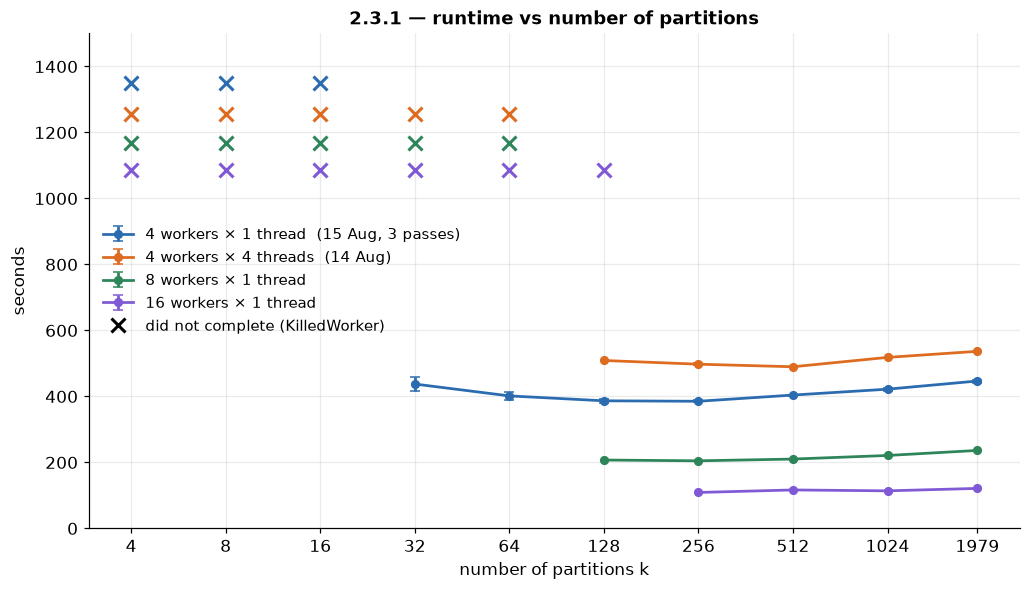

In [2]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
height = 1350

for table, color, name in [(one_thread, BLUE, "4 workers × 1 thread  (15 Aug, 3 passes)"),
                           (four_threads, ORANGE, "4 workers × 4 threads  (14 Aug)"),
                           (eight_workers, GREEN, "8 workers × 1 thread"),
                           (sixteen_workers, PURPLE, "16 workers × 1 thread")]:
    curve = completed(table)
    ax.errorbar(curve.index, curve["mean"], yerr=curve["std"], marker="o", ms=5,
                lw=1.8, capsize=3, color=color, label=name)
    failures = failed(table)
    ax.plot(failures, [height] * len(failures), "x", ms=9, mew=2, color=color)
    height *= 0.93

ax.set_xscale("log", base=2)
ax.set_xticks(K)
ax.set_xticklabels(K)
ax.set_ylim(0, 1500)
ax.set_xlabel("number of partitions k")
ax.set_ylabel("seconds")
ax.set_title("2.3.1 — runtime vs number of partitions")

handles, names = ax.get_legend_handles_labels()
ax.legend(handles + [Line2D([], [], ls="", marker="x", ms=9, mew=2, color="black")],
          names + ["did not complete (KilledWorker)"], loc="center left", fontsize=10)
fig.tight_layout()

## Runtime vs number of workers

Measured at `k=256`, in both complete campaigns. On the right, the speedup over a single worker against the ideal line.

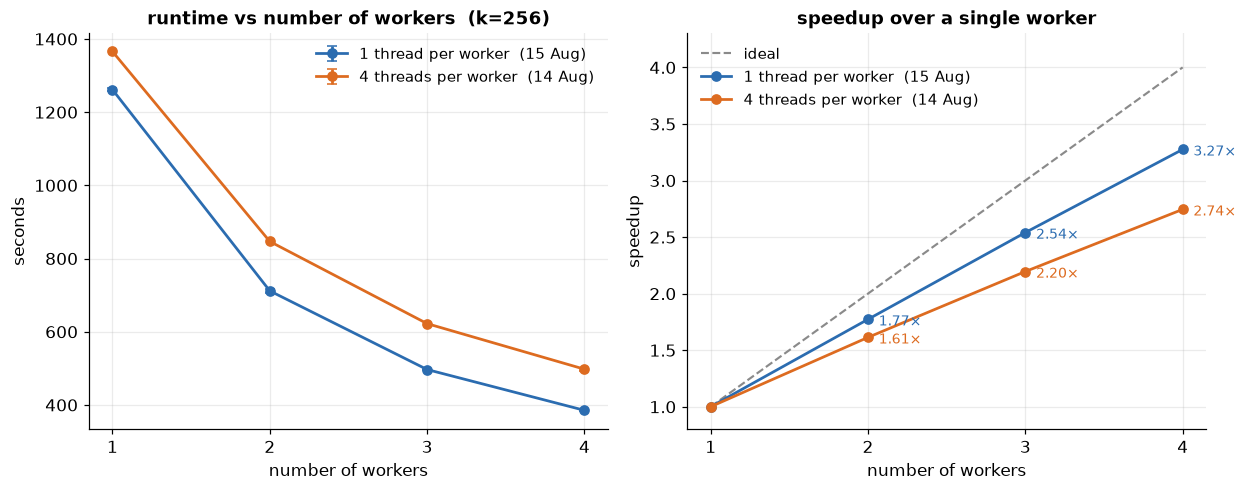

In [3]:
workers15 = (august15[(august15.split_out == 16) & (august15.thread == august15.worker) & (august15.partizioni == 256)]
             .groupby("worker").secondi.agg(["mean", "std"]))
workers14 = (august14[(august14.split_out == 16) & (august14.thread == 4 * august14.worker) & (august14.partizioni == 256)]
             .groupby("worker").secondi.agg(["mean", "std"]))

fig, (left, right) = plt.subplots(1, 2, figsize=(11.5, 4.6))
right.plot([1, 2, 3, 4], [1, 2, 3, 4], ls="--", lw=1.4, color=GREY, label="ideal")

for curve, color, name in [(workers15, BLUE, "1 thread per worker  (15 Aug)"),
                           (workers14, ORANGE, "4 threads per worker  (14 Aug)")]:
    speedup = curve["mean"].iloc[0] / curve["mean"]
    left.errorbar(curve.index, curve["mean"], yerr=curve["std"], marker="o", ms=6,
                  lw=1.8, capsize=3, color=color, label=name)
    right.plot(curve.index, speedup, marker="o", ms=6, lw=1.8, color=color, label=name)
    for workers, value in speedup.items():
        if workers > 1:
            right.annotate(f"{value:.2f}×", (workers, value), textcoords="offset points",
                           xytext=(7, -4), fontsize=9, color=color)

left.set_xticks([1, 2, 3, 4])
left.set_xlabel("number of workers")
left.set_ylabel("seconds")
left.set_title("runtime vs number of workers  (k=256)")
left.legend(fontsize=10)

right.set_xticks([1, 2, 3, 4])
right.set_ylim(0.8, 4.3)
right.set_xlabel("number of workers")
right.set_ylabel("speedup")
right.set_title("speedup over a single worker")
right.legend(fontsize=10)
fig.tight_layout()

## Threads per worker, and how the Reduce is closed

On the left, the three threads-per-worker values measured at `k=256`. On the right, the Reduce done with `foldby` (`split_out=0`) against the DataFrame one (`split_out=16`), everything else being equal. Both from the 15 August campaign.

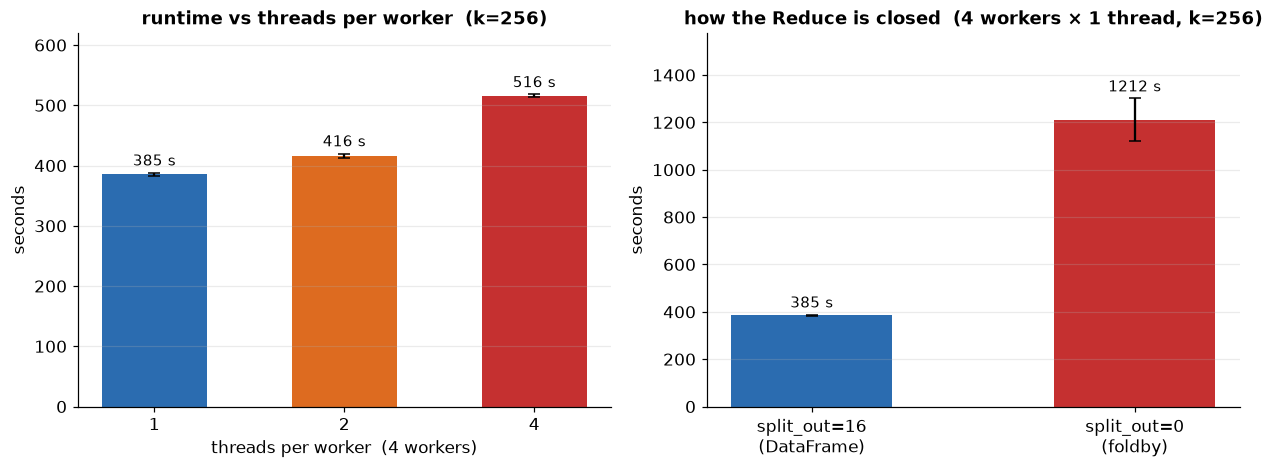

In [4]:
threads = august15[(august15.split_out == 16) & (august15.partizioni == 256) & (august15.worker == 4)].copy()
threads["per_worker"] = threads.thread // threads.worker
by_thread = threads.groupby("per_worker").secondi.agg(["mean", "std"])
reference = august15[august15.curva == "riferimento"].secondi.agg(["mean", "std"])
foldby = august15[august15.curva == "foldby"].secondi.agg(["mean", "std"])

fig, (left, right) = plt.subplots(1, 2, figsize=(11.5, 4.4))

bars = left.bar([str(n) for n in by_thread.index], by_thread["mean"], yerr=by_thread["std"],
                color=[BLUE, ORANGE, RED], width=0.55, capsize=4)
for bar, seconds, sd in zip(bars, by_thread["mean"], by_thread["std"]):
    left.text(bar.get_x() + bar.get_width() / 2, seconds + sd + 12, f"{seconds:.0f} s",
              ha="center", fontsize=10)
left.set_xlabel("threads per worker  (4 workers)")
left.set_ylabel("seconds")
left.set_ylim(0, by_thread["mean"].max() * 1.2)
left.set_title("runtime vs threads per worker  (k=256)")
left.grid(axis="x", visible=False)

values = [reference["mean"], foldby["mean"]]
errors = [reference["std"], foldby["std"]]
bars = right.bar(["split_out=16\n(DataFrame)", "split_out=0\n(foldby)"], values, yerr=errors,
                 color=[BLUE, RED], width=0.5, capsize=4)
for bar, seconds, sd in zip(bars, values, errors):
    right.text(bar.get_x() + bar.get_width() / 2, seconds + sd + 30, f"{seconds:.0f} s",
               ha="center", fontsize=10)
right.set_ylabel("seconds")
right.set_ylim(0, max(values) * 1.3)
right.set_title("how the Reduce is closed  (4 workers × 1 thread, k=256)")
right.grid(axis="x", visible=False)
fig.tight_layout()

## Memory peak vs number of partitions

The worker RSS peak during each measurement of the 15 August campaign, and the peak of a single task measured with no cluster. The red line is the worker memory limit (7.1 GB); the crosses are the `k` values that did not complete.

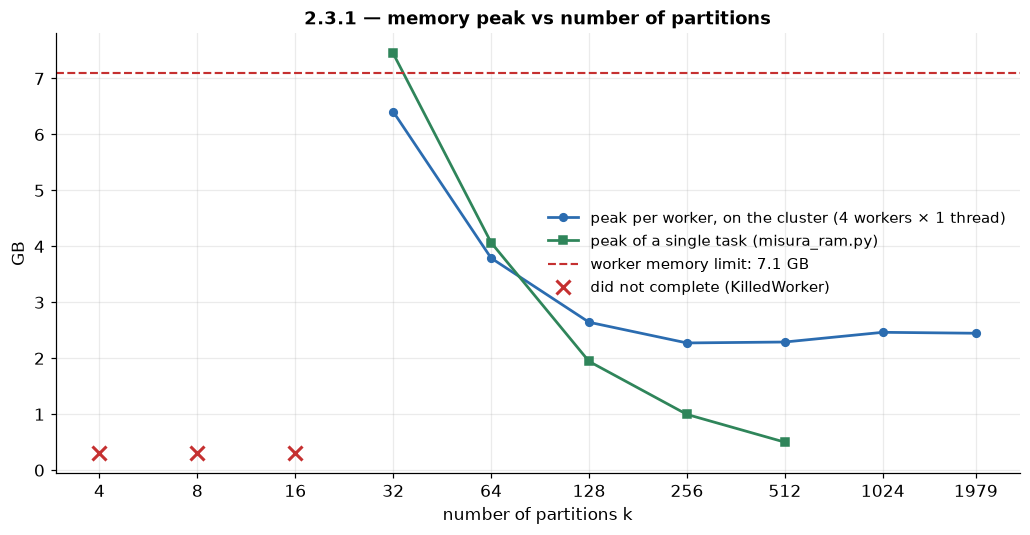

In [5]:
peaks = one_thread[one_thread.picco_gb.notna()].groupby("partizioni").picco_gb.mean()
failures = failed(one_thread)

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.plot(peaks.index, peaks.values, marker="o", ms=5, lw=1.8, color=BLUE,
        label="peak per worker, on the cluster (4 workers × 1 thread)")
ax.plot(single_task.k, single_task.picco_gb, marker="s", ms=5, lw=1.8, color=GREEN,
        label="peak of a single task (misura_ram.py)")
ax.axhline(7.1, ls="--", lw=1.4, color=RED, label="worker memory limit: 7.1 GB")
ax.plot(failures, [0.3] * len(failures), "x", ms=9, mew=2, color=RED,
        label="did not complete (KilledWorker)")

ax.set_xscale("log", base=2)
ax.set_xticks(K)
ax.set_xticklabels(K)
ax.set_xlabel("number of partitions k")
ax.set_ylabel("GB")
ax.set_title("2.3.1 — memory peak vs number of partitions")
ax.legend(fontsize=10, loc="center right")
fig.tight_layout()